# KLASIFIKASI KUALITAS TIN STABILIZER MT-620 - XGBoost
### Dataset: `Data_Chemical_MT620_Only_Final.xlsx`

---
**Alur Lengkap:**
1. Import Libraries & Load Data
2. Eksplorasi Data (EDA)
3. Pembersihan Data
4. Encoding APE (Clear = 1)
5. KNN Imputation
6. Labeling Per-Batch
7. Split Data 80/20
8. Analisis Keseimbangan Kelas
9. Training XGBoost + Early Stopping
10. **Learning Curve** (deteksi overfitting/underfitting)
11. **Training Loss Curve**
12. K-Fold Cross Validation
13. Prediksi & Metrik Evaluasi
14. Confusion Matrix
15. Feature Importance
16. Ringkasan Akhir

---

## 1. IMPORT LIBRARIES & LOAD DATA

In [28]:
# Import library utama
import pandas as pd                        # manipulasi data tabular (DataFrame)
import numpy as np                         # operasi matematika dan array numerik
import matplotlib.pyplot as plt            # membuat grafik dan visualisasi
import matplotlib.patches as mpatches      # membuat legenda custom pada grafik
import seaborn as sns                      # visualisasi statistik
import warnings                            # menekan pesan peringatan

# Import scikit-learn
from sklearn.impute import KNNImputer                      # isi missing value dengan K-Nearest Neighbors
from sklearn.model_selection import (
    train_test_split,                                      # pisahkan data jadi training dan validasi
    cross_val_score,                                       # evaluasi model dengan K-Fold CV
    StratifiedKFold,                                       # K-Fold yang menjaga proporsi kelas
    learning_curve                                         # hitung skor berbagai ukuran data
)
from sklearn.metrics import (
    accuracy_score,                                        # persentase prediksi benar
    precision_score,                                       # dari prediksi positif, berapa yang benar
    recall_score,                                          # dari data positif, berapa yang terdeteksi
    f1_score,                                              # harmonik mean precision dan recall
    confusion_matrix,                                      # matriks TP, TN, FP, FN
    classification_report,                                 # laporan lengkap metrik per kelas
    ConfusionMatrixDisplay                                 # visualisasi confusion matrix
)

# Import XGBoost
from xgboost import XGBClassifier          # model XGBoost untuk klasifikasi

# Konfigurasi
warnings.filterwarnings('ignore')          # sembunyikan peringatan
plt.style.use('default')                   # style default matplotlib
sns.set_palette('husl')                    # palet warna seaborn
plt.rcParams['figure.dpi'] = 100          # resolusi grafik

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


In [29]:
# Load data dari file Excel
FILE_PATH = 'Data_Chemical_MT620_Only_Final.xlsx'          # nama file dataset
df_raw = pd.read_excel(FILE_PATH)                          # baca file Excel menjadi DataFrame

print(f'File     : {FILE_PATH}')
print(f'Baris    : {len(df_raw)}')
print(f'Kolom    : {len(df_raw.columns)}')
print('Daftar Kolom:')
for i, col in enumerate(df_raw.columns, 1):                # enumerate = beri nomor urut saat iterasi
    print(f'  {i:2d}. {col}')

File     : Data_Chemical_MT620_Only_Final.xlsx
Baris    : 1780
Kolom    : 24
Daftar Kolom:
   1. ID
   2. Nama Chemical
   3. Nama
   4. Tanggal
   5. Jam Masuk
   6. Batch
   7. Deskripsi
   8. Status
   9. Transmission
  10. APE
  11. Tinx
  12. RI
  13. SG
  14. Acid
  15. Sulfur
  16. Water
  17. Mono
  18. Yellow
  19. EH
  20. Visco
  21. PT
  22. Created At
  23. Updated At
  24. Orang


## 2. EKSPLORASI DATA (EDA)

In [30]:
# Definisi kolom yang akan diproses
PARAM_COLS = [
    'Transmission',   # ketransmisian cahaya (%)
    'Tinx',           # kadar tin (%)
    'RI',             # refractive index
    'SG',             # specific gravity
    'Acid',           # acid value
    'Sulfur',         # kadar sulfur (%)
    'Water',          # kadar air (%)
    'Mono',           # monomethyltin (%)
    'Yellow',         # yellowish index
    'EH',             # 2-ethylhexyl content
    'Visco',          # viscosity
    'PT'              # Pt-Co color
]
CAT_COL = 'APE'       # kolom Appearance (Clear atau tidak)

print(f'Parameter numerik : {len(PARAM_COLS)}')
print(f'Kolom kategorikal : {CAT_COL}')

Parameter numerik : 12
Kolom kategorikal : APE


In [31]:
# Tampilkan 5 baris pertama
print('5 Baris Pertama Dataset:')
df_raw.head()          # .head() = tampilkan 5 baris pertama

5 Baris Pertama Dataset:


,ID,Nama Chemical,Nama,Tanggal,Jam Masuk,Batch,Deskripsi,Status,Transmission,APE,...,Sulfur,Water,Mono,Yellow,EH,Visco,PT,Created At,Updated At,Orang
0,11,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:21,TG2024L28,ANALISIS ALL PARAMETER,Approve,99.275,Clear,...,12.081,3.48,-,7.84,0.0001,47.2,10,2025-05-07T08:34:05.000000Z,2025-05-15T13:02:21.000000Z,Nikmatullah
1,12,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:43,TG2025A07,ANALISIS ALL PARAMETER,Approve,99.229,Clear,...,11.926,3.48,-,7.9,0.0005,45.07,10,2025-05-07T08:34:30.000000Z,2025-05-15T13:02:43.000000Z,Nikmatullah
2,13,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:44,TG2025B07-1,ANALISIS ALL PARAMETER,Approve,99.286,Clear,...,11.849,3.48,-,7.79,0.0001,49.4,10,2025-05-07T08:34:50.000000Z,2025-05-15T13:02:44.000000Z,Nikmatullah
3,38,Tinstab,MT-620,2025-05-09,2025-05-20 00:44:11,TG02025E05,Awal tengah akhir,Approve,99.216,Clear,...,12.099,3.49,NaN,7.85,NaN,49.6,10,2025-05-09T09:46:10.000000Z,2025-05-19T17:44:11.000000Z,Anto S
4,39,Tinstab,MT-620,2025-05-09,2025-05-19 23:56:22,TG02025E06,Awal tengah akhir,Approve,99.308,Clear,...,12.176,3.49,NaN,7.82,NaN,47.2,10,2025-05-09T09:46:53.000000Z,2025-05-19T16:56:22.000000Z,Anto S


In [32]:
# Info tipe data dan non-null count
print('Informasi Tipe Data:')
df_raw.info()          # .info() = tampilkan tipe data dan jumlah non-null

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1780 non-null   int64 
 1   Nama Chemical  1780 non-null   object
 2   Nama           1780 non-null   object
 3   Tanggal        1780 non-null   object
 4   Jam Masuk      1780 non-null   object
 5   Batch          1780 non-null   object
 6   Deskripsi      1780 non-null   object
 7   Status         1780 non-null   object
 8   Transmission   1763 non-null   object
 9   APE            1749 non-null   object
 10  Tinx           1051 non-null   object
 11  RI             877 non-null    object
 12  SG             1731 non-null   object
 13  Acid           883 non-null    object
 14  Sulfur         903 non-null    object
 15  Water          1204 non-null   object
 16  Mono           1060 non-null   object
 17  Yellow         1753 non-null   object
 18  EH     

In [33]:
# Hitung nilai tidak valid: NaN dan tanda '-'
def count_invalid(series):
    return series.apply(
        lambda x: pd.isna(x) or str(x).strip() in ['-', '']  # True jika tidak valid
    ).sum()

missing_total = df_raw[PARAM_COLS].apply(count_invalid)    # terapkan ke semua kolom

missing_tabel = pd.DataFrame({
    'Missing + Strip': missing_total,
    'Persen (%)': (missing_total / len(df_raw) * 100).round(2)
}).sort_values('Missing + Strip', ascending=False)

print('Nilai Tidak Valid per Kolom (NaN + tanda dash):')
print(missing_tabel.to_string())

Nilai Tidak Valid per Kolom (NaN + tanda dash):
              Missing + Strip  Persen (%)
Visco                    1559       87.58
EH                       1493       83.88
RI                        923       51.85
Acid                      919       51.63
Sulfur                    899       50.51
Tinx                      752       42.25
Mono                      747       41.97
Water                     583       32.75
PT                        104        5.84
SG                         50        2.81
Yellow                     27        1.52
Transmission               17        0.96


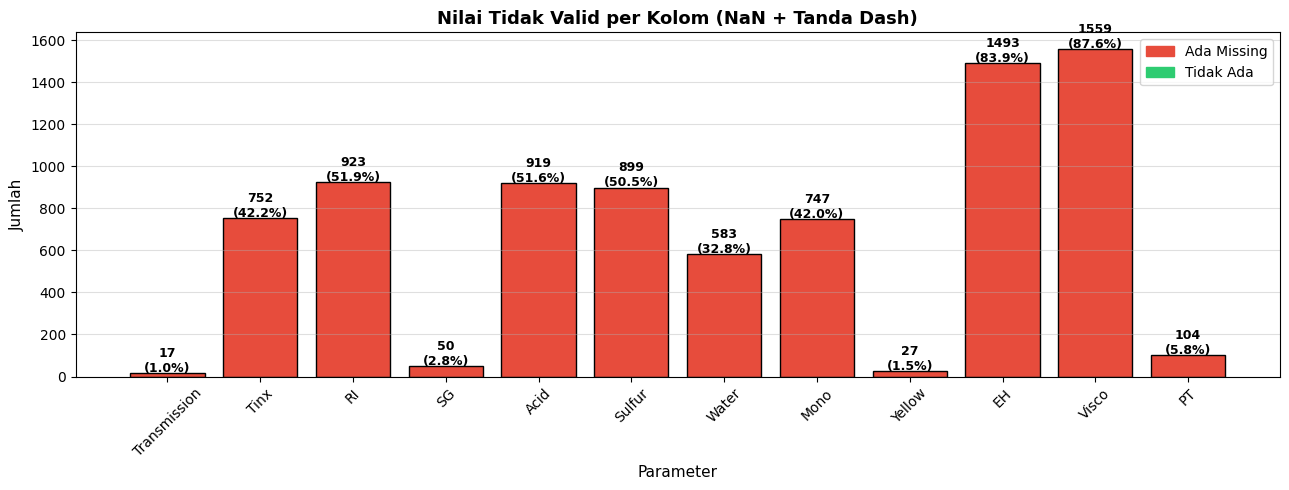

Grafik disimpan: eda_missing_values.png


In [34]:
# Visualisasi missing value
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_total.values]  # merah = ada missing
bars = ax.bar(missing_total.index, missing_total.values, color=colors, edgecolor='black')

for bar, val in zip(bars, missing_total.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df_raw)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('Nilai Tidak Valid per Kolom (NaN + Tanda Dash)', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameter', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Ada Missing'),
    mpatches.Patch(color='#2ecc71', label='Tidak Ada')
], fontsize=10)
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: eda_missing_values.png')

In [35]:
# Distribusi nilai unik kolom kategorikal
print('Nilai unik APE (Appearance):')
print(df_raw[CAT_COL].value_counts())     # .value_counts() = hitung kemunculan setiap nilai

print('\nNilai unik Status:')
print(df_raw['Status'].value_counts())

print(f'\nTotal Batch Unik: {df_raw["Batch"].nunique()}')
rows_per_batch = df_raw.groupby('Batch').size()    # groupby + size = hitung baris per batch
print('\nDistribusi jumlah baris per batch:')
print(rows_per_batch.value_counts().sort_index())

Nilai unik APE (Appearance):
APE
Clear       1451
clear        210
CLEAR         79
Bergaram       2
cLEAR          2
Cloudy         2
GARAM          1
5              1
yelow          1
Name: count, dtype: int64

Nilai unik Status:
Status
Approve            1776
Analisa Selesai       2
Pengajuan             1
Proses Analisa        1
Name: count, dtype: int64

Total Batch Unik: 975

Distribusi jumlah baris per batch:
1    183
2    779
3     13
Name: count, dtype: int64


## 3. PEMBERSIHAN DATA

In [36]:
# Salin data agar data asli tidak berubah
df = df_raw.copy()             # .copy() = buat salinan independen

# Ganti tanda '-' dan string kosong dengan NaN di kolom numerik
for col in PARAM_COLS:         # iterasi setiap kolom parameter
    df[col] = df[col].apply(
        lambda x: np.nan if str(x).strip() in ['-', '', 'nan'] else x
        # lambda = fungsi anonim satu baris
        # np.nan = nilai kosong numerik (Not a Number)
    )
    # Konversi ke tipe numerik; nilai yang tidak bisa dikonversi -> NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_after = df[PARAM_COLS].isnull().sum()
print('Missing values (NaN) setelah pembersihan:')
print(missing_after)
print(f'\nTotal missing: {missing_after.sum()}')

Missing values (NaN) setelah pembersihan:
Transmission      22
Tinx             752
RI               923
SG                54
Acid             919
Sulfur           899
Water            583
Mono             749
Yellow            31
EH              1493
Visco           1560
PT               105
dtype: int64

Total missing: 8090


## 4. ENCODING FITUR KATEGORIKAL (APE)

Kolom **APE** di-encode:
- `Clear`, `clear`, `CLEAR`, `cLEAR` -> **1** (jernih = bagus)
- `Bergaram`, `Cloudy`, `GARAM`, dll -> **0** (tidak jernih)

In [37]:
print('Nilai APE sebelum encoding:')
print(df[CAT_COL].value_counts())
print()

# Encode: lowercase == 'clear' -> 1, selain itu -> 0
df['APE_encoded'] = df[CAT_COL].apply(
    lambda x: 1 if str(x).strip().lower() == 'clear' else 0
    # str(x)  = konversi ke string (aman untuk NaN)
    # .strip() = hapus spasi di kiri/kanan
    # .lower() = ubah ke huruf kecil (Clear = clear = CLEAR)
)

print('Hasil encoding APE:')
print(df['APE_encoded'].value_counts().rename({1: 'Clear = 1', 0: 'Not Clear = 0'}))

Nilai APE sebelum encoding:
APE
Clear       1451
clear        210
CLEAR         79
Bergaram       2
cLEAR          2
Cloudy         2
GARAM          1
5              1
yelow          1
Name: count, dtype: int64

Hasil encoding APE:
APE_encoded
Clear = 1        1742
Not Clear = 0      38
Name: count, dtype: int64


## 5. KNN IMPUTATION

**KNN Imputer** mengisi nilai kosong dengan rata-rata **K tetangga terdekat**.
Lebih akurat dari mean/median karena mempertimbangkan konteks data lain.

In [38]:
# Gabungkan semua kolom fitur: 12 numerik + 1 encoded = 13 fitur
FEATURE_COLS = PARAM_COLS + ['APE_encoded']

print(f'Total fitur: {len(FEATURE_COLS)}')
print(f'Missing sebelum imputation: {df[FEATURE_COLS].isnull().sum().sum()}')

# Buat dan terapkan KNN Imputer
imputer = KNNImputer(n_neighbors=5)            # n_neighbors=5: gunakan 5 data terdekat
df[FEATURE_COLS] = imputer.fit_transform(      # fit_transform: pelajari pola lalu isi
    df[FEATURE_COLS]
)

# Bulatkan APE_encoded (KNN bisa menghasilkan desimal seperti 0.6)
df['APE_encoded'] = df['APE_encoded'].round().astype(int).clip(0, 1)
# .round()     = bulatkan ke angka bulat
# .astype(int) = konversi ke integer
# .clip(0, 1)  = batasi nilai antara 0 dan 1

print(f'Missing setelah KNN Imputation: {df[FEATURE_COLS].isnull().sum().sum()}')
print('KNN Imputation selesai!')

Total fitur: 13
Missing sebelum imputation: 8090
Missing setelah KNN Imputation: 0
KNN Imputation selesai!


In [39]:
# Statistik deskriptif setelah imputation
print('Statistik Deskriptif setelah Imputation:')
df[FEATURE_COLS].describe().round(4)   # count, mean, std, min, quartil, max

Statistik Deskriptif setelah Imputation:


,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT,APE_encoded
count,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000
mean,99.6639,19.0972,1.5081,1.1719,0.2370,11.9702,3.5044,22.0193,7.8299,0.0002,53.7445,6.8491,0.9787
std,21.1888,0.1794,0.0012,0.0098,0.3601,0.5183,0.2112,3.6964,0.2402,0.0004,2.4236,2.5884,0.1446
min,91.0840,15.3370,1.4838,1.0750,0.0192,0.2020,0.2030,0.0000,3.4900,0.0000,41.0000,2.0000,0.0000
25%,99.1160,19.0730,1.5078,1.1695,0.2006,11.9700,3.4780,21.4800,7.7000,0.0001,52.4600,5.0000,1.0000
50%,99.2020,19.0990,1.5082,1.1718,0.2030,12.0019,3.4800,22.0180,7.7900,0.0001,53.7800,5.0000,1.0000
75%,99.2580,19.1276,1.5085,1.1743,0.2102,12.0370,3.4840,22.5215,7.9025,0.0002,55.1600,10.0000,1.0000
max,993.0000,20.3126,1.5108,1.5087,11.9960,19.7000,7.9200,95.4900,12.0270,0.0098,73.5000,30.0000,1.0000


## 6. LABELING BERDASARKAN BATCH

**Spesifikasi TIN STABILIZER MT-620:**

| Parameter | Spesifikasi |
|-----------|-------------|
| Transmission | > 98 |
| APE | Clear (1) |
| Tinx | 18.8 - 19.2 |
| RI | 1.507 - 1.511 |
| SG | 1.160 - 1.180 |
| Acid | <= 3.0 |
| Sulfur | 11.5 - 12.5 |
| Water | < 3.5 |
| Mono | 19.5 - 28.5 |
| Yellow | < 9.0 |
| EH | < 0.7 |
| Visco | 40 - 80 |
| PT | <= 30 |

**Logika:** Per baris -> Passed/Not Passed | Per batch -> semua Passed = Layak(1), ada Not Passed = Tidak Layak(0)

In [40]:
# Definisi threshold spesifikasi
# Format: 'kolom': ('jenis', nilai...) - gt/lt/lte/eq/range
THRESHOLDS = {
    'Transmission' : ('gt',    98.0),
    'APE_encoded'  : ('eq',    1),
    'Tinx'         : ('range', 18.8,  19.2),
    'RI'           : ('range', 1.507, 1.511),
    'SG'           : ('range', 1.160, 1.180),
    'Acid'         : ('lte',   3.0),
    'Sulfur'       : ('range', 11.5,  12.5),
    'Water'        : ('lt',    3.5),
    'Mono'         : ('range', 19.5,  28.5),
    'Yellow'       : ('lt',    9.0),
    'EH'           : ('lt',    0.7),
    'Visco'        : ('range', 40.0,  80.0),
    'PT'           : ('lte',   30.0),
}
print(f'Total parameter yang dicek: {len(THRESHOLDS)}')

Total parameter yang dicek: 13


In [41]:
# Fungsi cek status per baris
def check_row_passed(row):
    """
    Periksa satu baris terhadap semua threshold.
    Return 'Passed' jika lolos semua, 'Not Passed' jika ada yang gagal.
    """
    for param, spec in THRESHOLDS.items():   # iterasi tiap parameter
        val  = row[param]                    # ambil nilai parameter
        kind = spec[0]                       # jenis kondisi
        if pd.isna(val): return 'Not Passed'
        if kind == 'gt'    and not (val >  spec[1]):             return 'Not Passed'
        if kind == 'lt'    and not (val <  spec[1]):             return 'Not Passed'
        if kind == 'lte'   and not (val <= spec[1]):             return 'Not Passed'
        if kind == 'eq'    and val != spec[1]:                   return 'Not Passed'
        if kind == 'range' and not (spec[1] <= val <= spec[2]):  return 'Not Passed'
    return 'Passed'

# Terapkan ke setiap baris (axis=1 = per baris)
df['Row_Status'] = df.apply(check_row_passed, axis=1)

print('Hasil pengecekan per baris:')
print(df['Row_Status'].value_counts())
print(f'\nPassed    : {(df["Row_Status"]=="Passed").mean()*100:.1f}%')
print(f'Not Passed: {(df["Row_Status"]=="Not Passed").mean()*100:.1f}%')

Hasil pengecekan per baris:
Row_Status
Passed        1490
Not Passed     290
Name: count, dtype: int64

Passed    : 83.7%
Not Passed: 16.3%


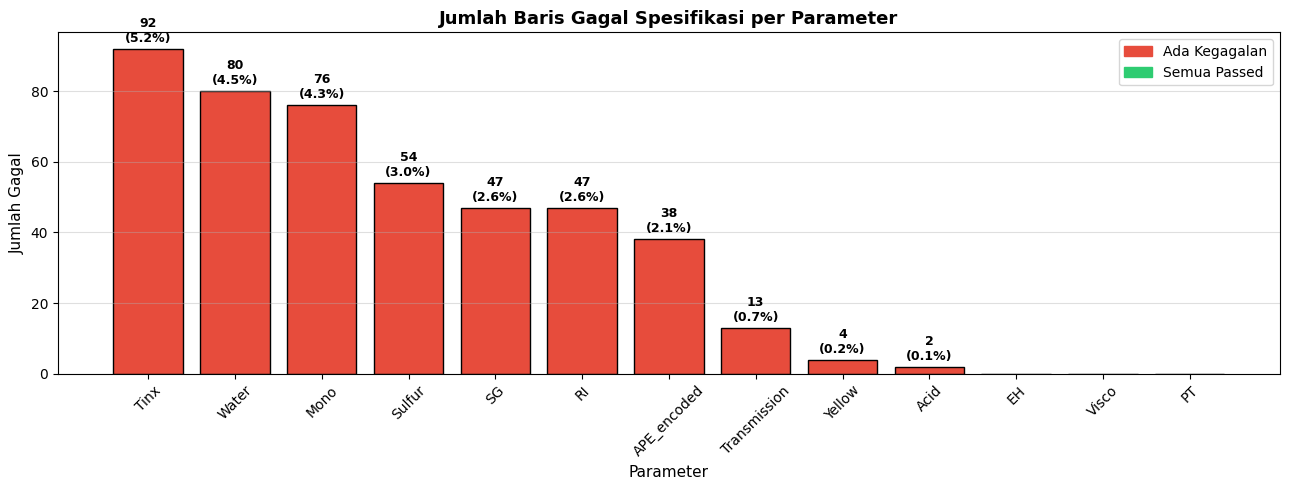

Grafik disimpan: parameter_gagal.png


In [42]:
# Urutkan dari yang paling banyak gagal
fail_series = pd.Series(fail_count).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))

# Warna: merah = ada kegagalan, hijau = semua passed
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in fail_series.values]

# Untuk bar dengan nilai 0, tampilkan tinggi minimal agar tetap kelihatan
display_vals = [v if v > 0 else 0.5 for v in fail_series.values]  # nilai 0 diganti 0.5 agar bar terlihat
bars = ax.bar(fail_series.index, display_vals, color=colors, edgecolor='black')

# Tambahkan label di atas setiap bar
for bar, val in zip(bars, fail_series.values):
    if val > 0:
        # Bar merah: tampilkan jumlah dan persentase kegagalan
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold', color='black')
    else:
        # Bar hijau: tampilkan teks 'Semua Passed' di atas bar
        ax.text(bar.get_x() + bar.get_width()/2, 1.5,
                'Semua\nPassed',
                ha='center', fontsize=8, fontweight='bold', color='#27ae60')

ax.set_title('Jumlah Baris Gagal Spesifikasi per Parameter', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameter', fontsize=11)
ax.set_ylabel('Jumlah Gagal', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
ax.set_ylim([0, fail_series.max() * 1.2])   # beri ruang di atas untuk label
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Ada Kegagalan'),
    mpatches.Patch(color='#2ecc71', label='Semua Passed (0 kegagalan)')
], fontsize=10)
plt.tight_layout()
plt.savefig('parameter_gagal.png', dpi=150, bbox_inches='tight')
plt.show()

# Cetak ringkasan
passed_params = [p for p, v in fail_count.items() if v == 0]
failed_params = [p for p, v in fail_count.items() if v > 0]
print(f'Grafik disimpan: parameter_gagal.png')
print(f'\nParameter SEMUA PASSED (0 kegagalan): {passed_params}')
print(f'Parameter ADA KEGAGALAN              : {failed_params}')

In [43]:
# Labeling per batch
# groupby('Batch') = kelompokkan berdasarkan batch
# .apply(lambda s: ...) = terapkan fungsi ke setiap kelompok
# (s == 'Passed').all() = True jika SEMUA baris Passed
batch_label = (
    df.groupby('Batch')['Row_Status']
    .apply(lambda s: 1 if (s == 'Passed').all() else 0)
    .rename('Label_Batch')
)

# merge = gabungkan label batch ke DataFrame utama
df = df.merge(batch_label, on='Batch', how='left')

print('=' * 55)
print('HASIL LABELING PER BATCH')
print('=' * 55)
print(f'Total batch unik      : {df["Batch"].nunique()}')
print(f'Batch LAYAK (1)       : {batch_label.sum()} ({batch_label.mean()*100:.1f}%)')
print(f'Batch TIDAK LAYAK (0) : {(batch_label==0).sum()} ({(1-batch_label.mean())*100:.1f}%)')
print()
print('Distribusi label pada baris:')
print(df['Label_Batch'].value_counts().rename({1: 'Layak (1)', 0: 'Tidak Layak (0)'}))

HASIL LABELING PER BATCH
Total batch unik      : 975
Batch LAYAK (1)       : 704 (72.2%)
Batch TIDAK LAYAK (0) : 271 (27.8%)

Distribusi label pada baris:
Label_Batch
Layak (1)          1300
Tidak Layak (0)     480
Name: count, dtype: int64


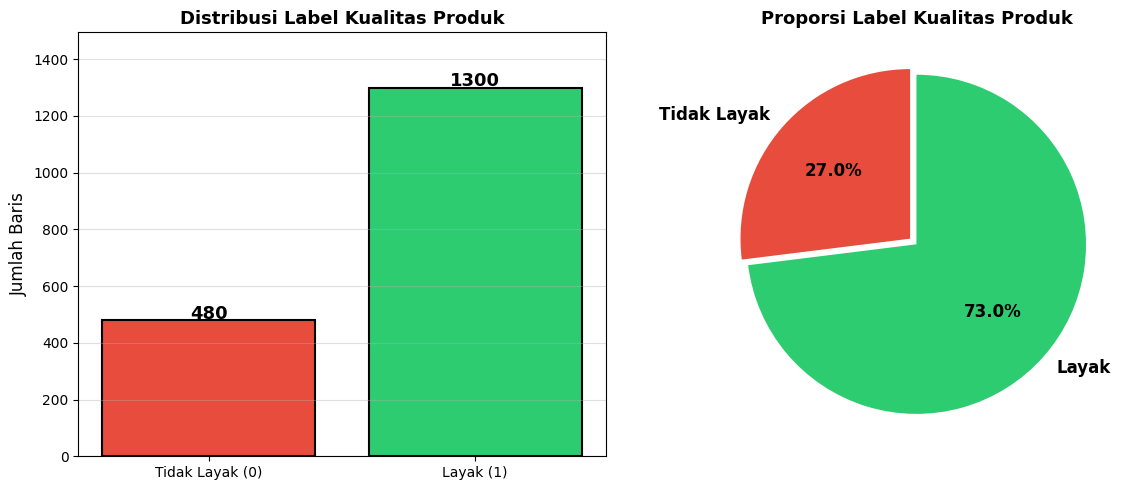

Grafik disimpan: distribusi_label.png


In [44]:
# Visualisasi distribusi label
label_counts = df['Label_Batch'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clrs = ['#e74c3c', '#2ecc71']

# Bar chart
bars = axes[0].bar(['Tidak Layak (0)', 'Layak (1)'], label_counts.values,
                    color=clrs, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Baris', fontsize=12)
axes[0].set_title('Distribusi Label Kualitas Produk', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_ylim([0, max(label_counts.values) * 1.15])

# Pie chart
axes[1].pie(label_counts.values, labels=['Tidak Layak', 'Layak'],
            autopct='%1.1f%%', colors=clrs, startangle=90, explode=[0.05, 0],
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Label Kualitas Produk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: distribusi_label.png')

## 7. SPLIT DATA - 80% Training, 20% Validasi

In [45]:
# Pisahkan fitur (X) dan target (y)
X = df[FEATURE_COLS].copy()          # X = fitur input (13 kolom)
y = df['Label_Batch'].copy()         # y = label yang diprediksi

print(f'Shape X: {X.shape}  -> {X.shape[0]} baris, {X.shape[1]} fitur')
print(f'Shape y: {y.shape}')

# Validasi: pastikan ada kedua kelas
assert y.nunique() >= 2, 'ERROR: Hanya ada 1 kelas!'

# Split 80% training / 20% validasi
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,      # 20% untuk validasi
    random_state=42,    # seed untuk reproduktifitas
    stratify=y          # jaga proporsi kelas di kedua set
)

print('\n' + '=' * 55)
print('SPLIT DATA BERHASIL!')
print('=' * 55)
print(f'Training  : {len(X_train)} baris ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Layak(1): {y_train.sum()} | Tidak Layak(0): {(y_train==0).sum()}')
print(f'Validasi  : {len(X_val)} baris ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Layak(1): {y_val.sum()} | Tidak Layak(0): {(y_val==0).sum()}')
print('=' * 55)

Shape X: (1780, 13)  -> 1780 baris, 13 fitur
Shape y: (1780,)

SPLIT DATA BERHASIL!
Training  : 1424 baris (80.0%)
  Layak(1): 1040 | Tidak Layak(0): 384
Validasi  : 356 baris (20.0%)
  Layak(1): 260 | Tidak Layak(0): 96


## 8. ANALISIS KESEIMBANGAN KELAS

In [46]:
# Hitung rasio kelas untuk scale_pos_weight
n_neg = (y_train == 0).sum()          # jumlah Tidak Layak di training
n_pos = (y_train == 1).sum()          # jumlah Layak di training
scale_pw = round(n_neg / n_pos, 4)    # rasio = nilai scale_pos_weight

print('=' * 55)
print('ANALISIS KESEIMBANGAN KELAS')
print('=' * 55)
print(f'Tidak Layak (0) : {n_neg} ({n_neg/len(y_train)*100:.1f}%)')
print(f'Layak (1)       : {n_pos} ({n_pos/len(y_train)*100:.1f}%)')
print(f'Rasio (0/1)     : {scale_pw}')
print()
# scale_pos_weight memberikan bobot lebih pada kelas minoritas
# agar model tidak bias ke kelas mayoritas
if scale_pw < 0.5 or scale_pw > 2.0:
    print(f'Data tidak seimbang! scale_pos_weight = {scale_pw} akan digunakan.')
else:
    print('Data cukup seimbang (rasio < 2:1).')
print('=' * 55)

ANALISIS KESEIMBANGAN KELAS
Tidak Layak (0) : 384 (27.0%)
Layak (1)       : 1040 (73.0%)
Rasio (0/1)     : 0.3692

Data tidak seimbang! scale_pos_weight = 0.3692 akan digunakan.


## 9. TRAINING MODEL XGBOOST + EARLY STOPPING

**Strategi Anti-Overfitting:**

| Teknik | Parameter | Penjelasan |
|--------|-----------|------------|
| Reg L1 | `reg_alpha=0.1` | Dorong bobot fitur ke nol |
| Reg L2 | `reg_lambda=2.0` | Cegah bobot terlalu besar |
| Min split gain | `gamma=0.5` | Split hanya jika loss cukup turun |
| Min leaf | `min_child_weight=5` | Cegah split pada data kecil |
| Subsample | `subsample=0.8` | 80% data acak per pohon |
| Colsample | `colsample_bytree=0.8` | 80% fitur acak per pohon |
| **Early Stop** | `early_stopping_rounds=30` | **Hentikan jika tidak ada perbaikan 30 ronde** |

In [47]:
# Inisialisasi model XGBoost dengan hyperparameter anti-overfitting
model = XGBClassifier(
    n_estimators=500,           # jumlah pohon MAKSIMAL (early stopping hentikan lebih awal)
    max_depth=4,                # kedalaman pohon (lebih dangkal = lebih general)
    learning_rate=0.05,         # learning rate (lebih kecil = belajar lebih hati-hati)
    subsample=0.8,              # 80% baris digunakan acak per pohon
    colsample_bytree=0.8,       # 80% fitur digunakan acak per pohon
    gamma=0.5,                  # minimum penurunan loss agar split dibuat
    min_child_weight=5,         # minimum sampel di leaf node
    reg_alpha=0.1,              # regularisasi L1 (Lasso)
    reg_lambda=2.0,             # regularisasi L2 (Ridge)
    scale_pos_weight=scale_pw,  # kompensasi ketidakseimbangan kelas
    eval_metric='logloss',        # metrik pantau saat training (XGBoost 3.x: di konstruktor)
    early_stopping_rounds=30,     # XGBoost 3.x: early stopping di konstruktor, bukan di .fit()
    random_state=42               # seed reproduktifitas
)

print('Model XGBoost berhasil diinisialisasi!')
print(f'  Max pohon      : {model.n_estimators}')
print(f'  Max depth      : {model.max_depth}')
print(f'  Learning rate  : {model.learning_rate}')
print(f'  L1 alpha       : {model.reg_alpha}')
print(f'  L2 lambda      : {model.reg_lambda}')

Model XGBoost berhasil diinisialisasi!
  Max pohon      : 500
  Max depth      : 4
  Learning rate  : 0.05
  L1 alpha       : 0.1
  L2 lambda      : 2.0


In [48]:
# Training dengan early stopping
# Catatan: eval_metric TIDAK diletakkan di sini, melainkan di XGBClassifier() sebelumnya
# karena versi XGBoost terbaru tidak menerima eval_metric sebagai argumen .fit()
print('Melatih model...')

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),   # pantau log loss pada data training
              (X_val,   y_val)],    # pantau log loss pada data validasi
    verbose=False                   # jangan tampilkan log per iterasi
    # early_stopping_rounds sudah diset di XGBClassifier() - XGBoost 3.x
)

best_iter = model.best_iteration    # indeks iterasi terbaik (0-based)

print('Training selesai!')
print(f'  Pohon optimal : {best_iter + 1} (dari {model.n_estimators} max)')

Melatih model...
Training selesai!
  Pohon optimal : 394 (dari 500 max)


## 10. LEARNING CURVE

Menunjukkan performa model seiring bertambahnya data training.

| Kondisi | Ciri |
|---------|------|
| **Fit Baik** | Kedua kurva tinggi & berdekatan |
| **Overfitting** | Training jauh lebih tinggi dari Validasi |
| **Underfitting** | Keduanya rendah |

In [49]:
print('Menghitung Learning Curve...')

# Model khusus learning curve (tanpa early stopping)
model_lc = XGBClassifier(
    n_estimators=best_iter + 1, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, gamma=0.5, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=2.0, scale_pos_weight=scale_pw,
    eval_metric='logloss', random_state=42  # XGBoost 3.x: hapus use_label_encoder
)

# learning_curve: latih model berulang kali dengan ukuran training berbeda
train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X_train, y_train,
    cv=5,                                      # 5-fold CV untuk setiap ukuran
    scoring='f1',                              # metrik F1
    train_sizes=np.linspace(0.1, 1.0, 10),    # dari 10% ke 100% (10 titik)
    n_jobs=-1                                  # gunakan semua CPU
)

# Hitung rata-rata dan standar deviasi
train_mean = train_scores.mean(axis=1)  # rata-rata dari 5 fold
train_std  = train_scores.std(axis=1)   # standar deviasi
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

print('Learning Curve selesai!')

Menghitung Learning Curve...
Learning Curve selesai!


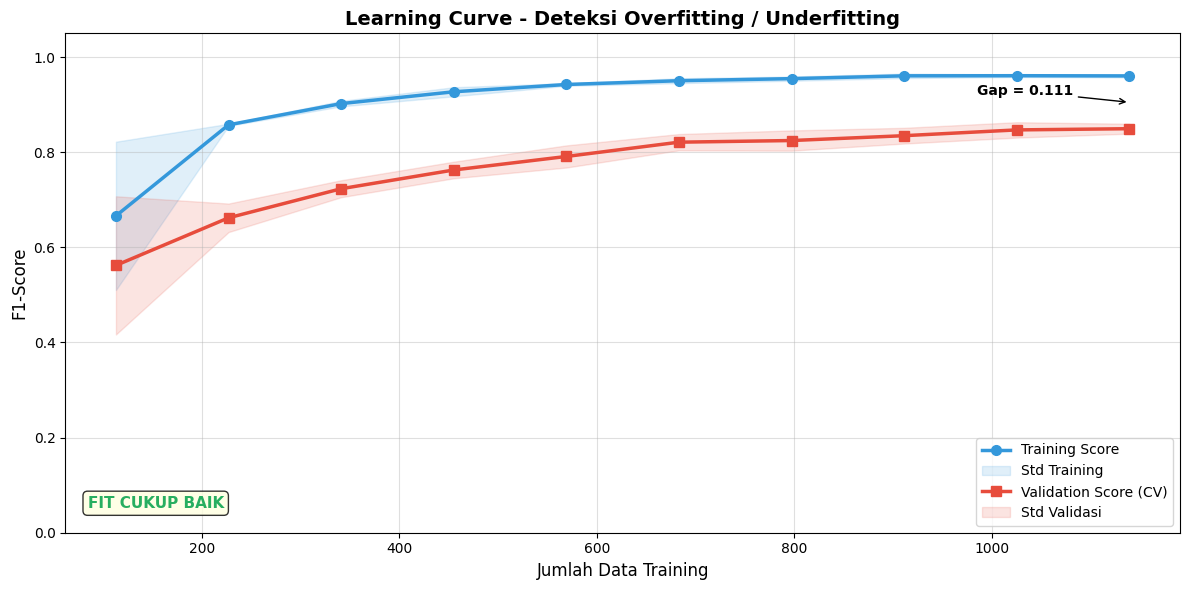

Grafik disimpan: learning_curve.png
Gap Train vs Val  : 0.1110
Training Score    : 0.9605
Validation Score  : 0.8495


In [50]:
# Visualisasi Learning Curve
fig, ax = plt.subplots(figsize=(12, 6))

# Kurva training (biru)
ax.plot(train_sizes, train_mean, color='#3498db', marker='o',
        linewidth=2.5, markersize=7, label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#3498db', label='Std Training')

# Kurva validasi (merah)
ax.plot(train_sizes, val_mean, color='#e74c3c', marker='s',
        linewidth=2.5, markersize=7, label='Validation Score (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e74c3c', label='Std Validasi')

# Gap akhir
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap = {final_gap:.3f}',
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
            xytext=(-110, 5), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Jumlah Data Training', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Learning Curve - Deteksi Overfitting / Underfitting',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.4)
ax.set_ylim([0, 1.05])

# Status otomatis
if final_gap < 0.05 and val_mean[-1] > 0.80:
    status, sc = 'FIT BAIK - gap kecil, generalisasi bagus', '#27ae60'
elif final_gap >= 0.15:
    status, sc = 'OVERFIT - gap besar', '#e74c3c'
elif val_mean[-1] < 0.70:
    status, sc = 'UNDERFIT - skor validasi rendah', '#e67e22'
else:
    status, sc = 'FIT CUKUP BAIK', '#27ae60'

ax.text(0.02, 0.05, status, transform=ax.transAxes, fontsize=11,
        color=sc, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan: learning_curve.png')
print(f'Gap Train vs Val  : {final_gap:.4f}')
print(f'Training Score    : {train_mean[-1]:.4f}')
print(f'Validation Score  : {val_mean[-1]:.4f}')

## 11. TRAINING LOSS CURVE

Log Loss per iterasi - semakin kecil semakin baik.
Jika validasi loss **mulai naik** sementara training turun = **Overfitting dimulai**.
**Early stopping** berhenti di titik terbaik (garis hijau).

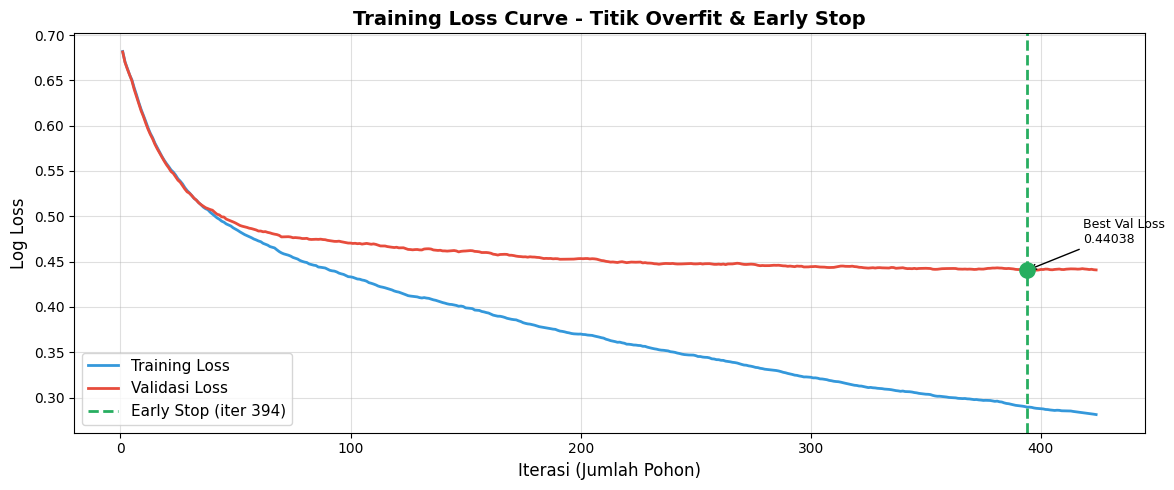

Grafik disimpan: training_loss_curve.png
Loss Training terbaik : 0.281185
Loss Validasi terbaik : 0.440385
Pohon optimal         : 394


In [51]:
# Ambil riwayat loss dari training
evals_result = model.evals_result()           # history log loss per iterasi
train_loss = evals_result['validation_0']['logloss']   # loss pada training set
val_loss   = evals_result['validation_1']['logloss']   # loss pada validasi set
iterations = range(1, len(train_loss) + 1)              # nomor iterasi

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(iterations, train_loss, color='#3498db', linewidth=2, label='Training Loss')
ax.plot(iterations, val_loss,   color='#e74c3c', linewidth=2, label='Validasi Loss')

# Garis vertikal di titik early stopping
ax.axvline(x=best_iter + 1, color='#27ae60', linestyle='--', linewidth=2,
           label=f'Early Stop (iter {best_iter + 1})')
ax.scatter([best_iter + 1], [val_loss[best_iter]], color='#27ae60', s=120, zorder=5)

ax.set_xlabel('Iterasi (Jumlah Pohon)', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('Training Loss Curve - Titik Overfit & Early Stop', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.4)

# Anotasi loss terbaik
ax.annotate(f'Best Val Loss\n{val_loss[best_iter]:.5f}',
            xy=(best_iter + 1, val_loss[best_iter]),
            xytext=(40, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: training_loss_curve.png')
print(f'Loss Training terbaik : {min(train_loss):.6f}')
print(f'Loss Validasi terbaik : {min(val_loss):.6f}')
print(f'Pohon optimal         : {best_iter + 1}')

## 12. K-FOLD CROSS VALIDATION (5-Fold Stratified)

In [52]:
K_FOLDS = 5
cv_strategy = StratifiedKFold(
    n_splits=K_FOLDS,      # bagi menjadi 5 fold
    shuffle=True,          # acak data sebelum dibagi
    random_state=42        # seed reproduktifitas
)

# Model untuk CV menggunakan jumlah pohon optimal
model_cv = XGBClassifier(
    n_estimators=best_iter + 1, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, gamma=0.5, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=2.0, scale_pos_weight=scale_pw,
    eval_metric='logloss', random_state=42  # XGBoost 3.x: hapus use_label_encoder
)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
cv_scores = {}              # simpan hasil semua metrik

print('=' * 60)
print(f'HASIL {K_FOLDS}-FOLD CROSS VALIDATION')
print('=' * 60)

for metric in scoring_metrics:
    scores = cross_val_score(
        model_cv, X_train, y_train,  # model dan data
        cv=cv_strategy,               # strategi pembagian
        scoring=metric                # metrik evaluasi
    )
    cv_scores[metric] = scores        # simpan hasil
    print(f'\n{metric.upper():10s}:')
    for i, s in enumerate(scores, 1):
        print(f'  Fold {i}: {s:.4f}')
    print(f'  Mean : {scores.mean():.4f}  |  Std: {scores.std():.4f}')

print('\n' + '=' * 60)
print('CROSS VALIDATION SELESAI!')
print('=' * 60)

HASIL 5-FOLD CROSS VALIDATION

ACCURACY  :
  Fold 1: 0.7825
  Fold 2: 0.7825
  Fold 3: 0.8561
  Fold 4: 0.7930
  Fold 5: 0.7852
  Mean : 0.7998  |  Std: 0.0284

PRECISION :
  Fold 1: 0.8476
  Fold 2: 0.8411
  Fold 3: 0.8920
  Fold 4: 0.8402
  Fold 5: 0.8451
  Mean : 0.8532  |  Std: 0.0196

RECALL    :
  Fold 1: 0.8558
  Fold 2: 0.8654
  Fold 3: 0.9135
  Fold 4: 0.8846
  Fold 5: 0.8654
  Mean : 0.8769  |  Std: 0.0205

F1        :
  Fold 1: 0.8517
  Fold 2: 0.8531
  Fold 3: 0.9026
  Fold 4: 0.8618
  Fold 5: 0.8551
  Mean : 0.8649  |  Std: 0.0192

CROSS VALIDATION SELESAI!


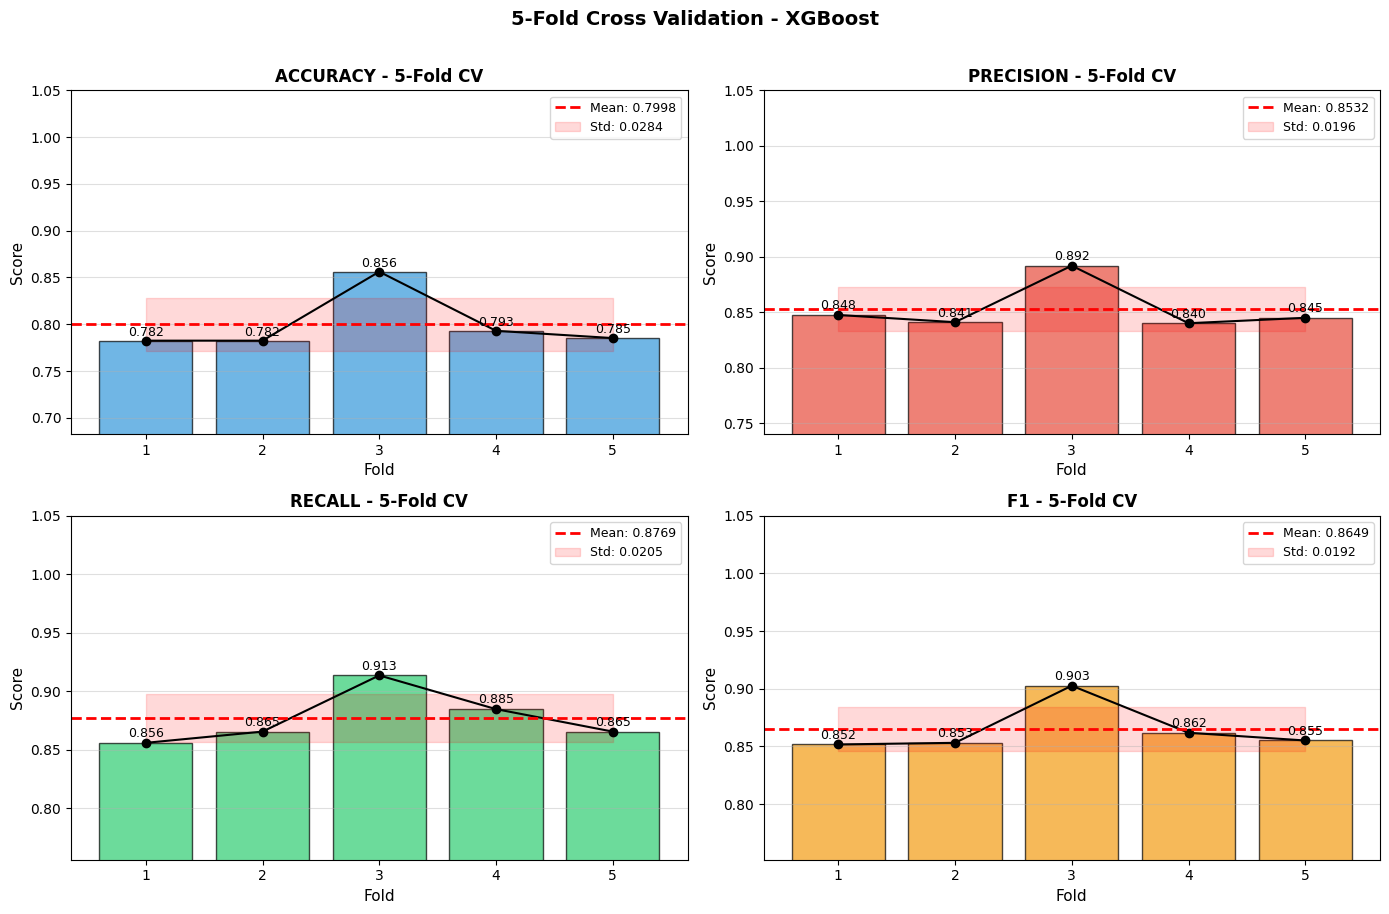

Grafik disimpan: cross_validation_results.png


In [53]:
# Visualisasi Cross Validation
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()            # ubah 2D menjadi 1D agar mudah diiterasi
metric_colors = {'accuracy': '#3498db', 'precision': '#e74c3c',
                 'recall': '#2ecc71', 'f1': '#f39c12'}

for idx, (metric, scores) in enumerate(cv_scores.items()):
    ax    = axes[idx]
    color = metric_colors[metric]
    folds = range(1, K_FOLDS + 1)

    ax.bar(folds, scores, color=color, alpha=0.7, edgecolor='black')
    ax.plot(folds, scores, marker='o', color='black', linewidth=1.5, markersize=6)

    mean_s = scores.mean()
    std_s  = scores.std()
    ax.axhline(mean_s, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_s:.4f}')
    ax.fill_between(folds, mean_s - std_s, mean_s + std_s,
                    alpha=0.15, color='red', label=f'Std: {std_s:.4f}')
    for fold, score in zip(folds, scores):
        ax.text(fold, score + 0.005, f'{score:.3f}', ha='center', fontsize=9)

    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric.upper()} - {K_FOLDS}-Fold CV', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks(list(folds))
    ax.set_ylim([max(0, scores.min() - 0.1), 1.05])
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('5-Fold Cross Validation - XGBoost', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: cross_validation_results.png')

## 13. PREDIKSI & METRIK EVALUASI

In [54]:
# Prediksi pada training dan validasi
y_train_pred  = model.predict(X_train)              # prediksi kelas (0/1)
y_train_proba = model.predict_proba(X_train)[:, 1]  # probabilitas kelas 1
y_val_pred    = model.predict(X_val)
y_val_proba   = model.predict_proba(X_val)[:, 1]

# Fungsi hitung metrik
def hitung_metrik(y_true, y_pred, nama):
    acc  = accuracy_score(y_true, y_pred)                   # (TP+TN)/Total
    prec = precision_score(y_true, y_pred, zero_division=0) # TP/(TP+FP)
    rec  = recall_score(y_true, y_pred, zero_division=0)    # TP/(TP+FN)
    f1   = f1_score(y_true, y_pred, zero_division=0)        # 2*(P*R)/(P+R)
    print(f'\n{"="*50}')
    print(f'METRIK EVALUASI - {nama}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{"="*50}')
    return acc, prec, rec, f1

train_acc, train_prec, train_rec, train_f1 = hitung_metrik(y_train, y_train_pred, 'DATA TRAINING')
val_acc,   val_prec,   val_rec,   val_f1   = hitung_metrik(y_val,   y_val_pred,   'DATA VALIDASI')


METRIK EVALUASI - DATA TRAINING
  Accuracy  : 0.9410  (94.10%)
  Precision : 0.9668
  Recall    : 0.9519
  F1-Score  : 0.9593

METRIK EVALUASI - DATA VALIDASI
  Accuracy  : 0.8202  (82.02%)
  Precision : 0.8657
  Recall    : 0.8923
  F1-Score  : 0.8788


In [55]:
# Diagnosis overfitting/underfitting
gap_acc = train_acc - val_acc
gap_f1  = train_f1  - val_f1

print('\n' + '=' * 55)
print('DIAGNOSIS MODEL')
print('=' * 55)
print(f'Gap Accuracy  (Train - Val): {gap_acc:+.4f}')
print(f'Gap F1-Score  (Train - Val): {gap_f1:+.4f}')
print()
if gap_f1 < 0.05 and val_f1 > 0.80:
    print('STATUS: FIT YANG BAIK')
elif gap_f1 >= 0.15:
    print('STATUS: OVERFIT')
elif val_f1 < 0.70:
    print('STATUS: UNDERFIT')
else:
    print('STATUS: FIT CUKUP BAIK')
print('=' * 55)


DIAGNOSIS MODEL
Gap Accuracy  (Train - Val): +0.1208
Gap F1-Score  (Train - Val): +0.0805

STATUS: FIT CUKUP BAIK


In [56]:
# Classification report lengkap
print('CLASSIFICATION REPORT - DATA VALIDASI')
print('=' * 65)
# Menampilkan precision, recall, f1 per kelas
print(classification_report(y_val, y_val_pred,
                             target_names=['Tidak Layak (0)', 'Layak (1)']))

CLASSIFICATION REPORT - DATA VALIDASI
                 precision    recall  f1-score   support

Tidak Layak (0)       0.68      0.62      0.65        96
      Layak (1)       0.87      0.89      0.88       260

       accuracy                           0.82       356
      macro avg       0.77      0.76      0.77       356
   weighted avg       0.82      0.82      0.82       356



## 14. CONFUSION MATRIX

In [57]:
# Hitung confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val   = confusion_matrix(y_val,   y_val_pred)

def print_cm_detail(cm, nama):
    tn, fp, fn, tp = cm.ravel()      # .ravel() = ubah 2x2 menjadi 4 nilai flat
    print(f'\nConfusion Matrix - {nama}:')
    print(f'  TN = {tn:4d}  Tidak Layak -> diprediksi Tidak Layak (BENAR)')
    print(f'  FP = {fp:4d}  Tidak Layak -> diprediksi Layak       (BAHAYA!)')
    print(f'  FN = {fn:4d}  Layak       -> diprediksi Tidak Layak (Pemborosan)')
    print(f'  TP = {tp:4d}  Layak       -> diprediksi Layak       (BENAR)')

print_cm_detail(cm_train, 'TRAINING')
print_cm_detail(cm_val,   'VALIDASI')


Confusion Matrix - TRAINING:
  TN =  350  Tidak Layak -> diprediksi Tidak Layak (BENAR)
  FP =   34  Tidak Layak -> diprediksi Layak       (BAHAYA!)
  FN =   50  Layak       -> diprediksi Tidak Layak (Pemborosan)
  TP =  990  Layak       -> diprediksi Layak       (BENAR)

Confusion Matrix - VALIDASI:
  TN =   60  Tidak Layak -> diprediksi Tidak Layak (BENAR)
  FP =   36  Tidak Layak -> diprediksi Layak       (BAHAYA!)
  FN =   28  Layak       -> diprediksi Tidak Layak (Pemborosan)
  TP =  232  Layak       -> diprediksi Layak       (BENAR)


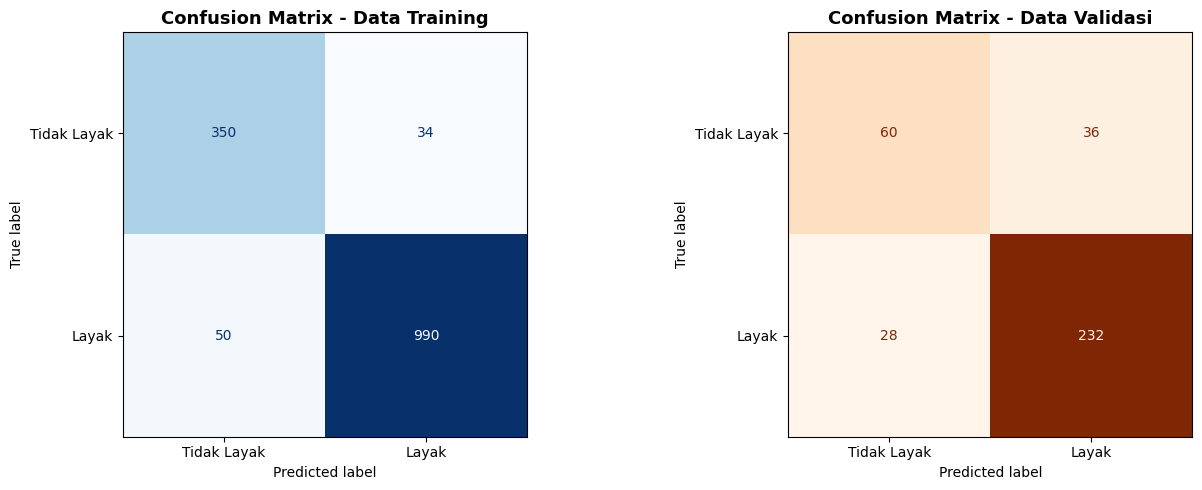

Grafik disimpan: confusion_matrix_day2.png


In [58]:
# Visualisasi confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training (biru)
ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=['Tidak Layak', 'Layak']
).plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
# cmap='Blues'     = palet warna biru
# values_format='d' = tampilkan angka integer
axes[0].set_title('Confusion Matrix - Data Training', fontsize=13, fontweight='bold')
axes[0].grid(False)

# Validasi (oranye)
ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=['Tidak Layak', 'Layak']
).plot(ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('Confusion Matrix - Data Validasi', fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrix_day2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: confusion_matrix_day2.png')

## 15. FEATURE IMPORTANCE

In [59]:
# Tabel feature importance
feat_imp = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : model.feature_importances_   # frekuensi fitur digunakan untuk split
}).sort_values('Importance', ascending=False
).reset_index(drop=True)

print('=' * 45)
print('FEATURE IMPORTANCE (XGBoost)')
print('=' * 45)
print(feat_imp.to_string(index=False))
print('=' * 45)

FEATURE IMPORTANCE (XGBoost)
     Feature  Importance
       Water    0.233176
        Tinx    0.110506
        Mono    0.109234
          RI    0.079141
      Sulfur    0.074356
          SG    0.073883
        Acid    0.064958
Transmission    0.054403
       Visco    0.052878
          PT    0.051249
          EH    0.049795
      Yellow    0.046421
 APE_encoded    0.000000


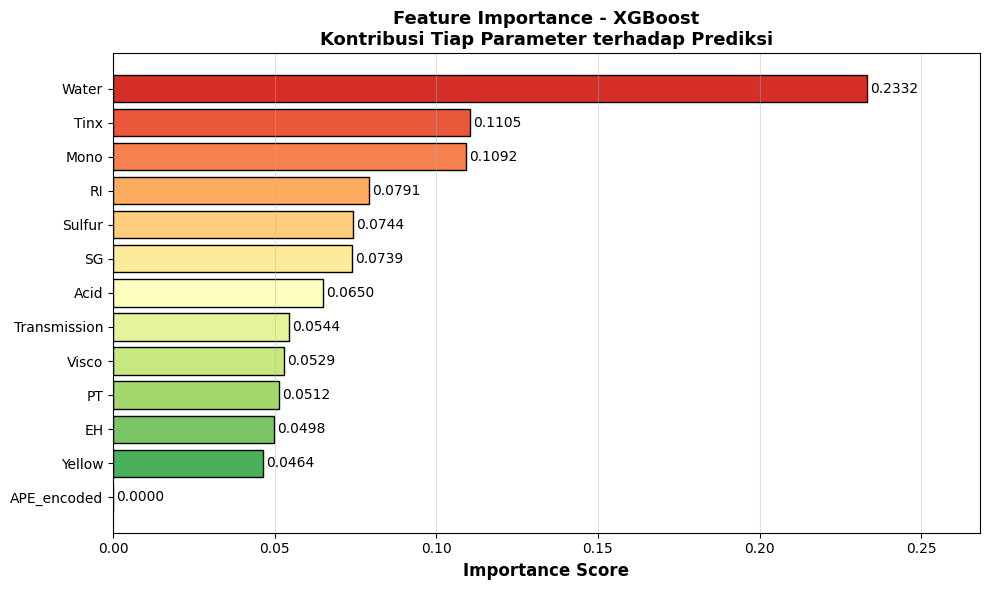

Grafik disimpan: feature_importance_day2.png


In [60]:
# Visualisasi feature importance
fig, ax = plt.subplots(figsize=(10, 6))

# Gradasi warna dari hijau (penting) ke merah (kurang penting)
palette = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feat_imp)))

# Horizontal bar (lebih mudah dibaca)
bars = ax.barh(
    feat_imp['Feature'][::-1],     # balik urutan agar yang terpenting di atas
    feat_imp['Importance'][::-1],
    color=palette[::-1], edgecolor='black'
)

# Label nilai di samping bar
for bar, val in zip(bars, feat_imp['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - XGBoost\nKontribusi Tiap Parameter terhadap Prediksi',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
ax.set_xlim([0, feat_imp['Importance'].max() * 1.15])
plt.tight_layout()
plt.savefig('feature_importance_day2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: feature_importance_day2.png')

## 16. PERBANDINGAN METRIK & RINGKASAN AKHIR

In [61]:
# Tabel perbandingan semua metrik
comparison_df = pd.DataFrame({
    'Metrik'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training' : [train_acc,  train_prec,  train_rec,  train_f1],
    'Validasi' : [val_acc,    val_prec,    val_rec,    val_f1],
    'CV Mean'  : [cv_scores['accuracy'].mean(),  cv_scores['precision'].mean(),
                  cv_scores['recall'].mean(),     cv_scores['f1'].mean()],
    'CV Std'   : [cv_scores['accuracy'].std(),   cv_scores['precision'].std(),
                  cv_scores['recall'].std(),      cv_scores['f1'].std()],
})
print('=' * 80)
print('TABEL PERBANDINGAN METRIK EVALUASI')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)

TABEL PERBANDINGAN METRIK EVALUASI
   Metrik  Training  Validasi  CV Mean   CV Std
 Accuracy  0.941011  0.820225 0.799849 0.028408
Precision  0.966797  0.865672 0.853202 0.019593
   Recall  0.951923  0.892308 0.876923 0.020533
 F1-Score  0.959302  0.878788 0.864860 0.019195


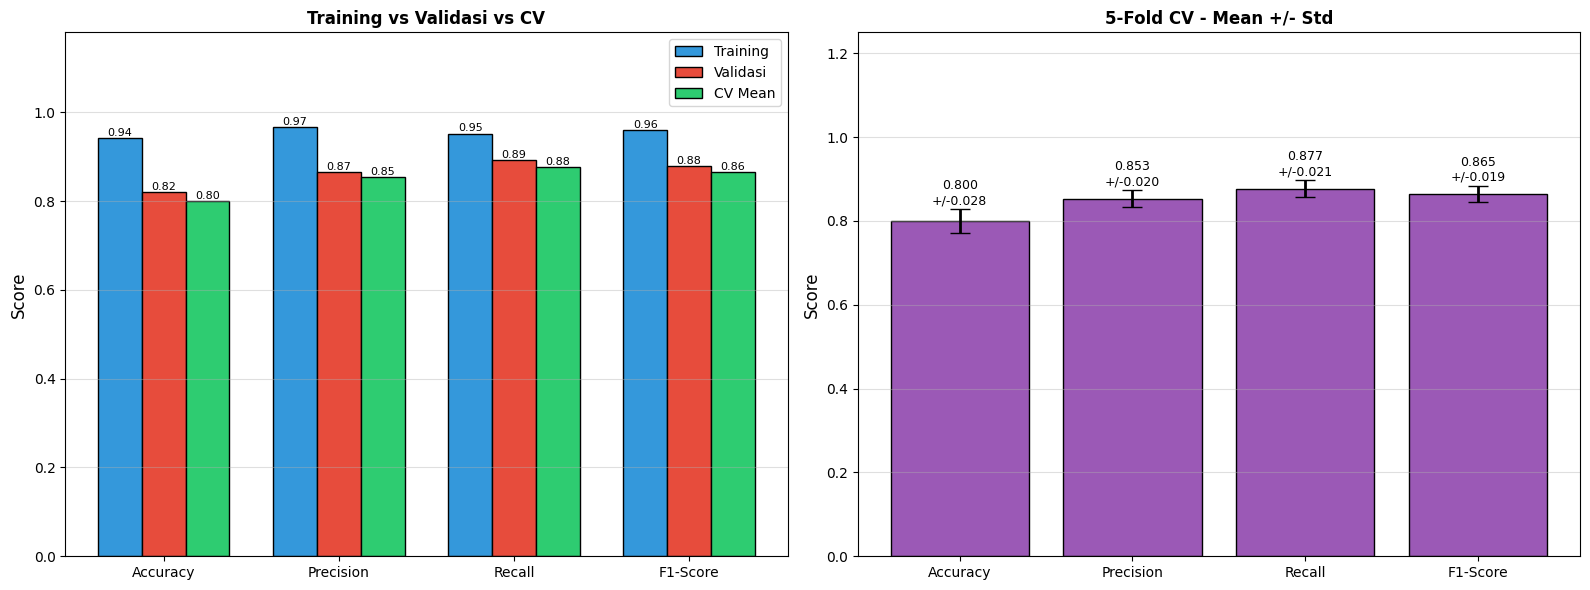

Grafik disimpan: metrics_comparison_day2.png


In [62]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))    # posisi sumbu X
w = 0.25                              # lebar bar

# Kiri: Training vs Validasi vs CV
b1 = axes[0].bar(x - w, comparison_df['Training'], w, label='Training', color='#3498db', edgecolor='black')
b2 = axes[0].bar(x,     comparison_df['Validasi'],  w, label='Validasi',  color='#e74c3c', edgecolor='black')
b3 = axes[0].bar(x + w, comparison_df['CV Mean'],   w, label='CV Mean',   color='#2ecc71', edgecolor='black')

for bg in [b1, b2, b3]:
    for bar in bg:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{bar.get_height():.2f}', ha='center', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Metrik'])
axes[0].set_ylim([0, 1.18])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Training vs Validasi vs CV', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

# Kanan: CV Mean +/- Std
axes[1].bar(x, comparison_df['CV Mean'],
            yerr=comparison_df['CV Std'],      # error bar
            color='#9b59b6', edgecolor='black', capsize=7,
            error_kw={'linewidth': 2, 'ecolor': 'black'})
for i, (m, s) in enumerate(zip(comparison_df['CV Mean'], comparison_df['CV Std'])):
    axes[1].text(i, m + s + 0.012, f'{m:.3f}\n+/-{s:.3f}', ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Metrik'])
axes[1].set_ylim([0, 1.25])
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(f'{K_FOLDS}-Fold CV - Mean +/- Std', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('metrics_comparison_day2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: metrics_comparison_day2.png')

In [63]:
# Simpan model
import pickle                           # library serialisasi Python

MODEL_FILE = 'xgboost_mt620_day2.pkl'
with open(MODEL_FILE, 'wb') as f:       # 'wb' = write binary
    pickle.dump(model, f)               # tulis objek model ke file
print(f'Model disimpan: {MODEL_FILE}')

Model disimpan: xgboost_mt620_day2.pkl


In [64]:
# Ringkasan akhir
print('\n' + '='*75)
print('RINGKASAN - KLASIFIKASI TIN STABILIZER MT-620 (Day 2)')
print('='*75)
print(f'\n1. DATA:')
print(f'   File        : {FILE_PATH}')
print(f'   Total Baris : {len(df)}')
print(f'   Total Batch : {df["Batch"].nunique()}')
print(f'   Fitur       : {len(FEATURE_COLS)}')
print(f'   Training    : {len(X_train)} | Validasi: {len(X_val)}')
print(f'\n2. MODEL:')
print(f'   Pohon optimal : {best_iter + 1} (dari {model.n_estimators} max)')
print(f'   Max depth     : {model.max_depth}')
print(f'   L1 / L2       : {model.reg_alpha} / {model.reg_lambda}')
print(f'\n3. CROSS-VALIDATION ({K_FOLDS}-Fold):')
for m, scores in cv_scores.items():
    print(f'   {m.capitalize():10s}: {scores.mean():.4f} +/- {scores.std():.4f}')
print(f'\n4. TRAINING :')
print(f'   Acc:{train_acc:.4f} | Prec:{train_prec:.4f} | Rec:{train_rec:.4f} | F1:{train_f1:.4f}')
print(f'\n5. VALIDASI :')
print(f'   Acc:{val_acc:.4f} | Prec:{val_prec:.4f} | Rec:{val_rec:.4f} | F1:{val_f1:.4f}')
print(f'\n6. DIAGNOSIS:')
gap_f1_final = train_f1 - val_f1
print(f'   Gap F1 (Train-Val): {gap_f1_final:+.4f}')
if gap_f1_final < 0.05: print('   Status: FIT BAIK')
elif gap_f1_final < 0.15: print('   Status: SEDIKIT OVERFIT (masih wajar)')
else: print('   Status: OVERFIT')
print(f'\n7. TOP 3 FITUR:')
for _, r in feat_imp.head(3).iterrows():
    print(f'   {r["Feature"]:15s}: {r["Importance"]:.4f}')
print('\n' + '='*75)
print('ANALISIS SELESAI!')
print('='*75)


RINGKASAN - KLASIFIKASI TIN STABILIZER MT-620 (Day 2)

1. DATA:
   File        : Data_Chemical_MT620_Only_Final.xlsx
   Total Baris : 1780
   Total Batch : 975
   Fitur       : 13
   Training    : 1424 | Validasi: 356

2. MODEL:
   Pohon optimal : 394 (dari 500 max)
   Max depth     : 4
   L1 / L2       : 0.1 / 2.0

3. CROSS-VALIDATION (5-Fold):
   Accuracy  : 0.7998 +/- 0.0284
   Precision : 0.8532 +/- 0.0196
   Recall    : 0.8769 +/- 0.0205
   F1        : 0.8649 +/- 0.0192

4. TRAINING :
   Acc:0.9410 | Prec:0.9668 | Rec:0.9519 | F1:0.9593

5. VALIDASI :
   Acc:0.8202 | Prec:0.8657 | Rec:0.8923 | F1:0.8788

6. DIAGNOSIS:
   Gap F1 (Train-Val): +0.0805
   Status: SEDIKIT OVERFIT (masih wajar)

7. TOP 3 FITUR:
   Water          : 0.2332
   Tinx           : 0.1105
   Mono           : 0.1092

ANALISIS SELESAI!


## PANDUAN MEMBACA KURVA

### Learning Curve
```
F1  |  Training ────────────
    |            Validation - - -
    |  (gap kecil = FIT BAIK)
    +──────────────────► ukuran data
```
- Gap kecil & skor tinggi = **FIT BAIK**
- Training >> Validasi = **OVERFITTING**
- Keduanya rendah = **UNDERFITTING**

### Training Loss Curve
```
Loss |\  Training Loss (terus turun)
     | \____  Validasi Loss (berhenti = Early Stop)
     +──────────────────────────► Iterasi
                  ^ Early Stop di sini
```

### Confusion Matrix
```
              PREDIKSI
           TL   |  L
AKTUAL TL | TN  | FP  <- FP = BAHAYA (produk buruk lolos!)
       L  | FN  | TP  <- FN = Pemborosan (produk baik ditolak)
```

---
*Notebook Day 2 - Klasifikasi Kualitas TIN STABILIZER MT-620*